In [5]:
import pandas as pd
import numpy as np

# **Loading Dataset**

In [6]:
df = pd.read_csv("Twitter_Data.csv")
df.head()


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65953 entries, 0 to 65952
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   clean_text  65952 non-null  object 
 1   category    65952 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.0+ MB


In [8]:
df.isnull().sum()


,0
clean_text,1
category,1


In [9]:
df = df.dropna(subset=['clean_text', 'category'])


In [10]:
df['category'] = df['category'].astype(int)


# **Class balance**

In [11]:
df['category'].value_counts(normalize=True) * 100


,proportion
category,
1,44.260133
0,33.981289
-1,21.758578


# **Feature Extraction**

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=3
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['category']


# **Training and Training**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# **Naive Bayes classification**

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.7349708134334015
              precision    recall  f1-score   support

          -1       0.80      0.46      0.59      2870
           0       0.81      0.70      0.75      4483
           1       0.68      0.90      0.77      5838

    accuracy                           0.73     13191
   macro avg       0.77      0.69      0.70     13191
weighted avg       0.75      0.73      0.73     13191



# **Support Vector Machine**

In [15]:
from sklearn.svm import LinearSVC

svm = LinearSVC(class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.9175195208854522
              precision    recall  f1-score   support

          -1       0.88      0.84      0.86      2870
           0       0.92      0.96      0.94      4483
           1       0.94      0.92      0.93      5838

    accuracy                           0.92     13191
   macro avg       0.91      0.91      0.91     13191
weighted avg       0.92      0.92      0.92     13191



# **Confusion Matrix**

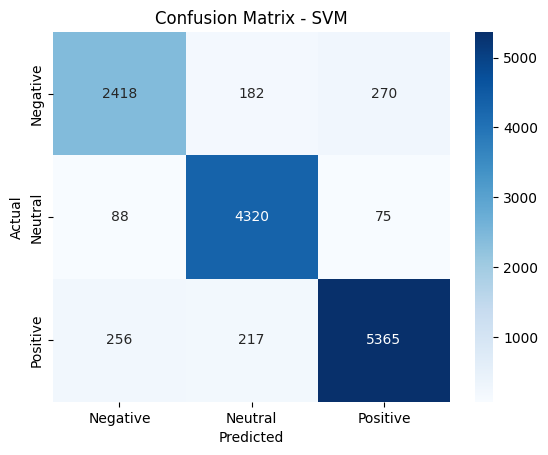

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


In [17]:
label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

def predict_sentiment(text):
    text_vector = vectorizer.transform([text])
    prediction = svm.predict(text_vector)[0]
    return label_map[prediction]


In [18]:
predict_sentiment("I hate You")

'Negative'

In [19]:
predict_sentiment("This place is beautiful")

'Positive'

In [20]:
predict_sentiment("Yesterday I went to the mall")

'Neutral'